# Fast transport through two curved interfaces

**Use case:** propagate a smooth, vector electric field through a macroscopic
dielectric element, then calculate its actual diffracted image field. This
notebook uses an 8-mm entrance aperture, a 10-mm vertex separation and
$\lambda_0=193.368$ nm. Both optical faces act on the field.
Lengths in the API are in mm; stored magnetic fields are $Z_0H_{\rm SI}$.

The acceleration is explicit: one ray per sampled point for each smooth phase
component, with vector Fresnel laws, optical path and ray-tube spreading.
The final current radiation retains diffraction. Every source direction is
propagated separately; no invariant-shift image model is used.

This is a **leading high-frequency approximation between interfaces**. It omits
intermediate aperture-edge diffraction and resonant feedback, and rejects
intermediate caustics, vignetting, grazing and evanescent transmission. It is
not a replacement for the general spectral method in arbitrary regimes.

In [1]:
# Locate this checkout and initialize inline figures.

from pathlib import Path
import sys
import json
import time

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()
)
sys.path.insert(0, str(root))
from IPython import get_ipython

get_ipython().run_line_magic("matplotlib", "inline")
import numpy as np
import matplotlib.pyplot as plt
from examples.notebook_tools import style, show, scalar_map, polarization_map, fwhm
from examples.macroscopic_element import configuration, response
from vecdiff.observables.electromagnetism import poynting, boundary_residuals
from vecdiff import plane_wave, sample_surface
from vecdiff.fields.eikonal_field import EikonalElectricField
from vecdiff.propagation.high_frequency import propagate_high_frequency

style()

## 1. What the approximation preserves

Write $E=A\exp(ik_0L)$, where $L$ is optical-path length and
$|\nabla L|=n$. Then
$$-i\nabla E=e^{ik_0L}\left(k_0 A\nabla L-i\nabla A\right).$$
The transported direction is $\hat u=\nabla L/n$. The envelope derivative is
omitted in this representation; a general interfering field need not admit
one phase. `EikonalElectricField` therefore requires an explicitly supplied
phase, gradient and transverse vector envelope. `ElectricSpectrum` instead
transports every supplied phase component separately, preserving linearity.

In one homogeneous segment, flux in a ray tube gives
$$|A_2|=|A_1|\sqrt{
\frac{|\hat u\cdot\hat n_1|\,dS_1}{|\hat u\cdot\hat n_2|\,dS_2}}.$$
Four displaced differential rays measure the area Jacobian, while the central
ray carries the field. The spectral Fresnel basis and coefficients still come
from `interfaces/fresnel.py`. No total-field phase unwrapping is used.

## 2. Specify the physical element and illumination

The entrance conic has $c=0.1\,{\rm mm}^{-1}$ and $K=-(1/1.5)^2$. It maps an
axial plane wave from air into a wave converging toward $z=30$ mm in glass.
The exit spherical cap has radius 12 mm and vertex $z=10$ mm. It refracts that
converging wave from $n=1.5$ into air with final focus $z=40$ mm.

The nominal Gaussian envelope has waist parameter 1 mm and $x$ polarization.
It underfills the 4-mm entrance radius, suppressing the omitted upstream edge
contribution. Its single-phase input is a leading WKB field, not an exact
Gaussian Maxwell solution; that approximation is measured below.

In [2]:
wavelength = 0.000193368
waist_mm = 1.0
assembly, aperture, focus = configuration()

carrier = plane_wave(wavelength=wavelength)
direction = carrier.wavevectors[0].real * wavelength / (2 * np.pi)
polarization = carrier.amplitudes[0]
incoming = EikonalElectricField(
    lambda p: p @ direction,
    lambda p: direction,
    lambda p: (
        np.exp(-(np.sum(p * p, axis=-1) - (p @ direction) ** 2) / waist_mm**2)[
            ..., None
        ]
        * polarization
    ),
    wavelength,
)

source_nr, source_nphi = 64, 128
sampling = sample_surface(
    assembly.interfaces[0].surface,
    (0, aperture),
    (0, 2 * np.pi),
    source_nr,
    source_nphi,
)

start = time.perf_counter()
result = propagate_high_frequency(incoming, assembly, sampling, apertures=(4.0, 3.5))
transport_seconds = time.perf_counter() - start
first, last = result.modes[0]

opl = last.optical_path + np.linalg.norm(focus - last.sampling.points, axis=-1)

# Stigmatic optical path is checked before plotting rays.
assert np.ptp(opl) / wavelength < 1e-7

**Read the result:** Both surfaces and the recovered optical path are shown together.

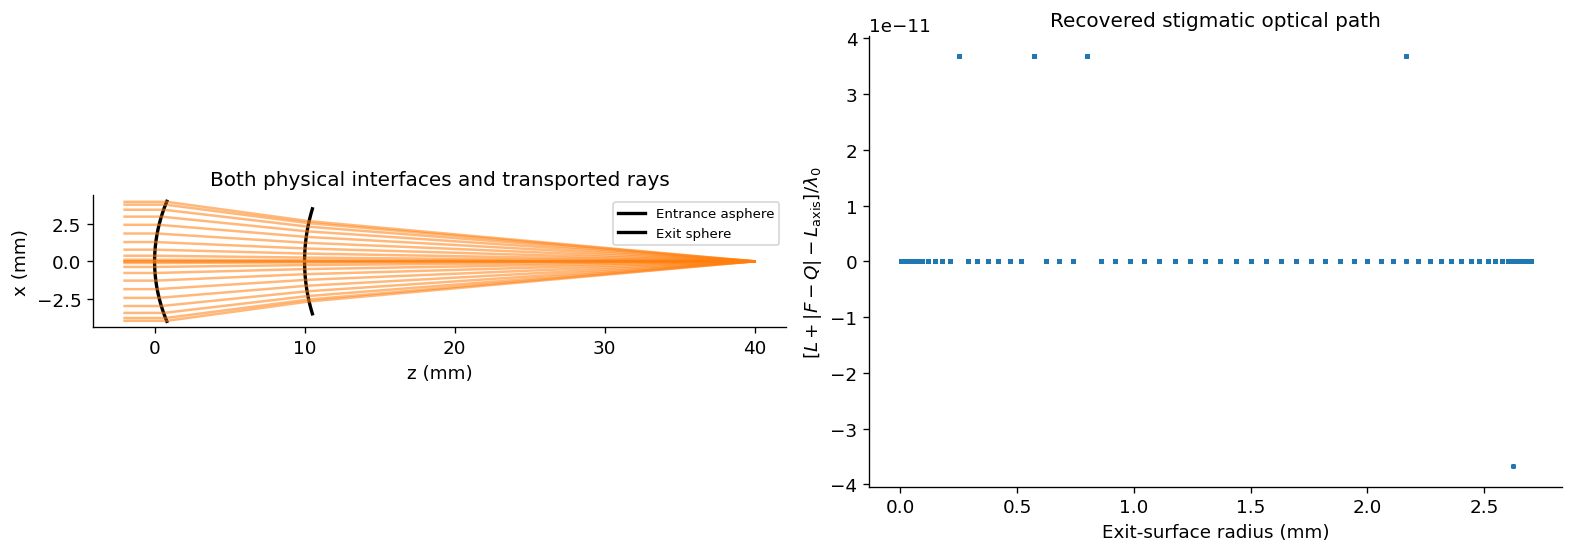

Transport through both faces: 0.0366 s; samples: 8,192; OPL spread: 7.349e-11 wavelengths


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout="constrained")

for interface, radius, label in zip(
    assembly.interfaces, [4.0, 3.5], ["Entrance asphere", "Exit sphere"]
):
    xg = np.linspace(-radius, radius, 501)
    zg = interface.surface.sag(abs(xg)) + interface.surface.frame.origin[2]
    axes[0].plot(zg, xg, "k", lw=2, label=label)

for index in np.arange(0, len(first.sampling.points), 128)[::6]:
    p = first.sampling.points[index]
    q = last.sampling.points[index]

    for sign in [-1, 1]:
        axes[0].plot(
            [-2, p[2], q[2], focus[2]],
            [sign * p[0], sign * p[0], sign * q[0], 0],
            color="tab:orange",
            alpha=0.55,
        )

axes[0].set(
    xlabel="z (mm)",
    ylabel="x (mm)",
    title="Both physical interfaces and transported rays",
    aspect="equal",
)
axes[0].legend(fontsize=8)
r = np.linalg.norm(last.sampling.points[:, :2], axis=-1)
axes[1].scatter(r, (opl - opl[0]) / wavelength, s=3)
axes[1].set(
    xlabel="Exit-surface radius (mm)",
    ylabel=r"$[L+|F-Q|-L_{\rm axis}]/\lambda_0$",
    title="Recovered stigmatic optical path",
)
show(fig, "09_two_interface_geometry")
print(
    f"Transport through both faces: {transport_seconds:.4f} s; samples: {len(last.sampling.points):,}; OPL spread: {np.ptp(opl) / wavelength:.3e} wavelengths"
)

## 3. Observe the two-face image in distinct planes

The final equivalent currents are constructed from the transmitted vector
fields on the **second** face. The following maps evaluate those currents.
All scalar panels use `cmap='hot'`; each component has its own explicit
colorbar, normalized to the same total electric-norm peak.
The spatial meridional map spans 46.4 µm axially and 7.73 µm transversely.
A separate on-axis lineout retains the broader 464-µm axial range.

### Focal observation plane: x–y at z = f

Fix z at the final focus (40 mm). Both axes are transverse image coordinates.

In [4]:
x = np.linspace(-20, 20, 161) * wavelength
X, Y = np.meshgrid(x, x)
start = time.perf_counter()
focal = result.transmitted.evaluate_local(
    focus + np.stack((X, Y, 0 * X), axis=-1), radius=5 * wavelength, backend="auto"
)
focal_seconds = time.perf_counter() - start
e = focal.electric
peak = np.sum(abs(e) ** 2, axis=-1).max()

### Meridional plane: x–z at y = 0

Fix y at zero and vary z across the focus. The vertical axis is $z-f$;
this is a longitudinal slice, not the transverse focal observation plane.

In [5]:
z = np.linspace(-120, 120, 193) * wavelength
XM, Z = np.meshgrid(x, z)
start = time.perf_counter()
meridional = result.transmitted.evaluate_local(
    focus + np.stack((XM, 0 * XM, Z), axis=-1), radius=5 * wavelength, backend="auto"
)
meridional_seconds = time.perf_counter() - start
em = meridional.electric
field_seconds = focal_seconds + meridional_seconds

**Focal-plane maps:** vector field components in x–y at z = f.

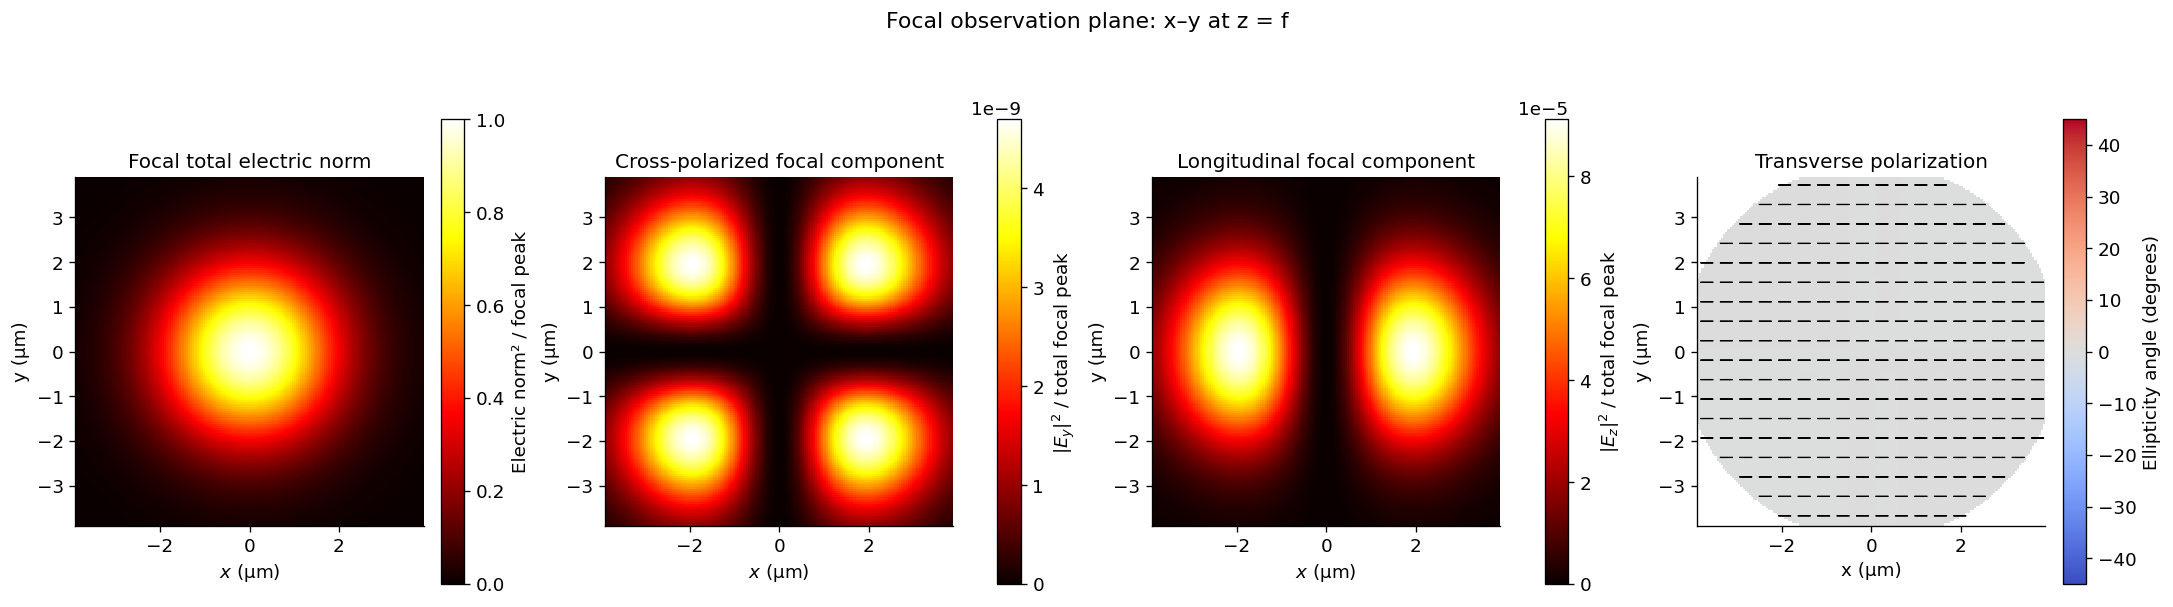

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5.5), layout="constrained")
fig.suptitle("Focal observation plane: x–y at z = f")

# Plot total and individual focal components against one focal peak.
scalar_map(
    fig,
    axes[0],
    np.sum(abs(e) ** 2, axis=-1) / peak,
    x * 1e3,
    x * 1e3,
    "Focal total electric norm",
    ylabel="y (µm)",
    label="Electric norm² / focal peak",
)
scalar_map(
    fig,
    axes[1],
    abs(e[..., 1]) ** 2 / peak,
    x * 1e3,
    x * 1e3,
    "Cross-polarized focal component",
    ylabel="y (µm)",
    label=r"$|E_y|^2$ / total focal peak",
)
scalar_map(
    fig,
    axes[2],
    abs(e[..., 2]) ** 2 / peak,
    x * 1e3,
    x * 1e3,
    "Longitudinal focal component",
    ylabel="y (µm)",
    label=r"$|E_z|^2$ / total focal peak",
)

# Polarization is also evaluated on the transverse focal grid.
polarization_map(fig, axes[3], e, x * 1e3, x * 1e3, title="Transverse polarization")
show(fig, "09_two_interface_focal_fields")

**Meridional maps:** the same transmitted currents observed along x–z at
y = 0. These plots are separate from the focal x–y maps above.

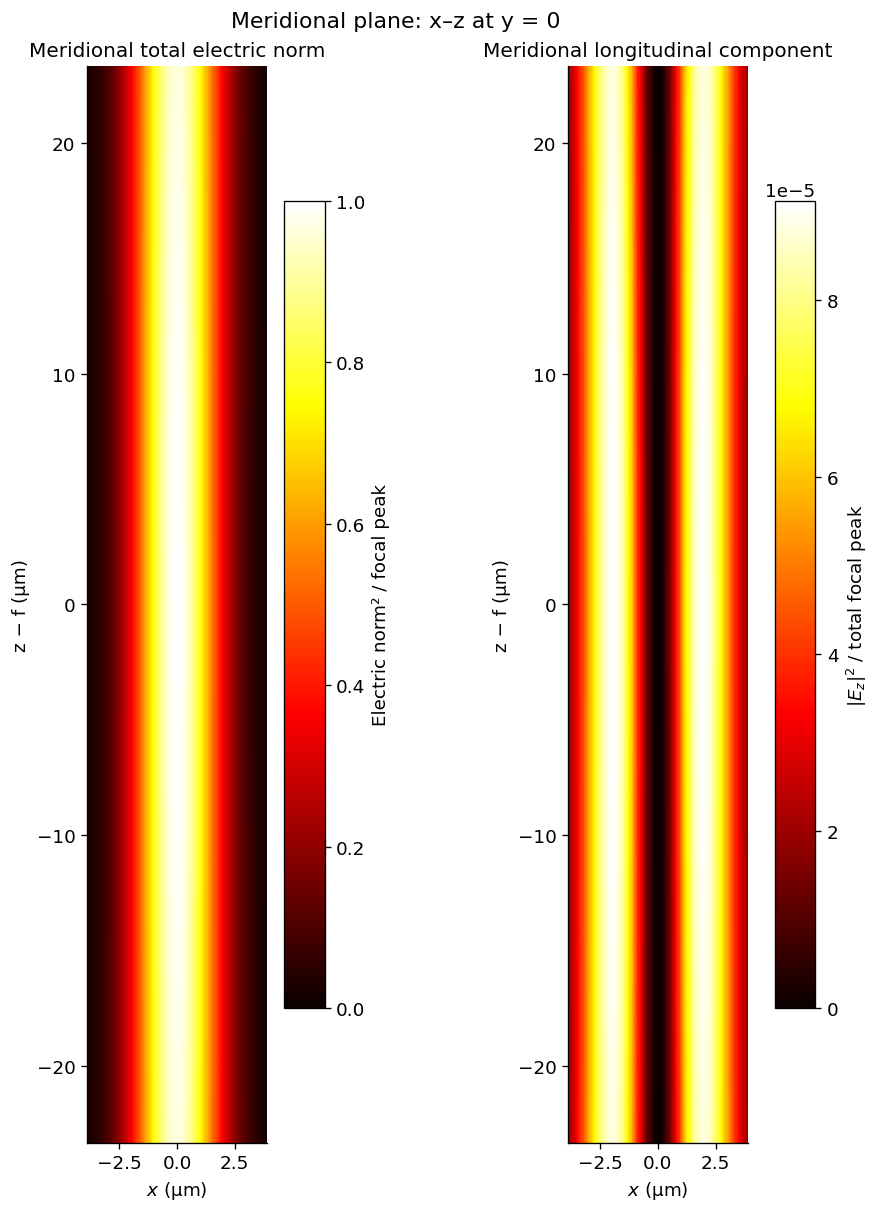

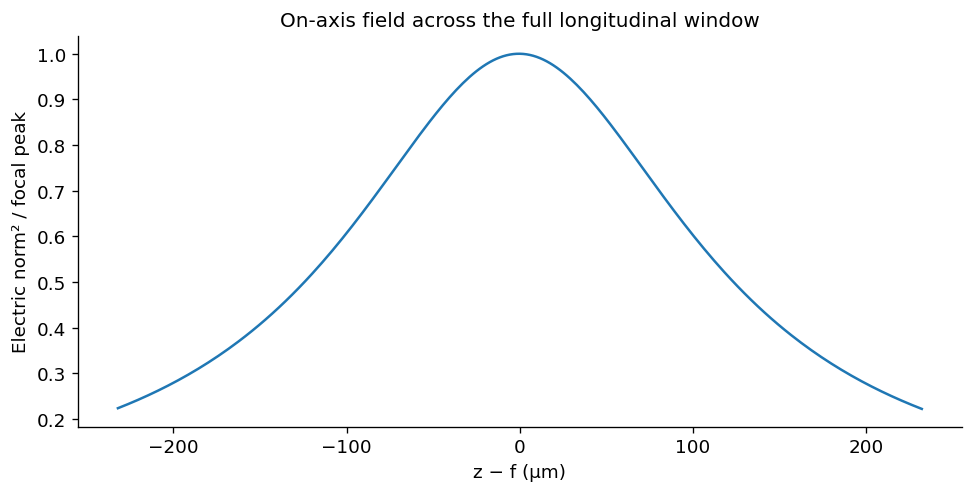

56,994 vector observations in 4.053 s; focal x FWHM=3.2517 µm


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8, 10), layout="constrained")
fig.suptitle("Meridional plane: x–z at y = 0")

# Use the same peak when comparing focal and meridional maps.
scalar_map(
    fig,
    axes[0],
    np.sum(abs(em) ** 2, axis=-1) / peak,
    x * 1e3,
    z * 1e3,
    "Meridional total electric norm",
    ylabel="z − f (µm)",
    label="Electric norm² / focal peak",
)
scalar_map(
    fig,
    axes[1],
    abs(em[..., 2]) ** 2 / peak,
    x * 1e3,
    z * 1e3,
    "Meridional longitudinal component",
    ylabel="z − f (µm)",
    label=r"$|E_z|^2$ / total focal peak",
)

show(fig, "09_two_interface_meridional_fields")

# Preserve the broader longitudinal view as a one-dimensional observable.
z_long = np.linspace(-1200, 1200, 241) * wavelength
axial_points = focus + np.stack((0 * z_long, 0 * z_long, z_long), axis=-1)
axial_field = result.transmitted.evaluate_local(
    axial_points, radius=5 * wavelength, backend="auto"
).electric

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.plot(z_long * 1e3, np.sum(abs(axial_field) ** 2, axis=-1) / peak)
ax.set(
    xlabel="z − f (µm)",
    ylabel="Electric norm² / focal peak",
    title="On-axis field across the full longitudinal window",
)
show(fig, "09_two_interface_axial_lineout")
print(
    f"{X.size + XM.size:,} vector observations in {field_seconds:.3f} s; focal x FWHM={fwhm(x * 1e3, np.sum(abs(e[len(x) // 2]) ** 2, axis=-1)):.4f} µm"
)

## 4. A displaced source is propagated through both faces

To illuminate the full numerical aperture in this field-angle study, use a
uniform plane wave instead of the underfilling Gaussian above. The paraxial
effective focal length is 45 mm; this predicts the observation centre only.
Actual rays, Fresnel transformations, phases and spreading are recomputed for
each angle, followed by current radiation. A translated on-axis line is drawn
solely as a comparison and never used to calculate an image.

In [8]:
# Propagate displaced source directions independently through both faces.

angles = [0.0, 0.02, 0.1]
line_x = np.linspace(-20, 20, 401) * wavelength
lines = []

for angle in angles:
    system_field, _ = response(angle, wavelength=wavelength)

    # Use the predicted centre only to place the evaluation line.
    center = focus + np.array([45 * np.tan(np.deg2rad(angle)), 0, 0])
    values = system_field.transmitted.evaluate_local(
        center + np.c_[line_x, 0 * line_x, 0 * line_x],
        radius=5 * wavelength,
        backend="auto",
    )
    lines.append(np.sum(abs(values.electric) ** 2, axis=-1))

**Read the result:** Compare recomputed off-axis profiles with a shifted on-axis control.

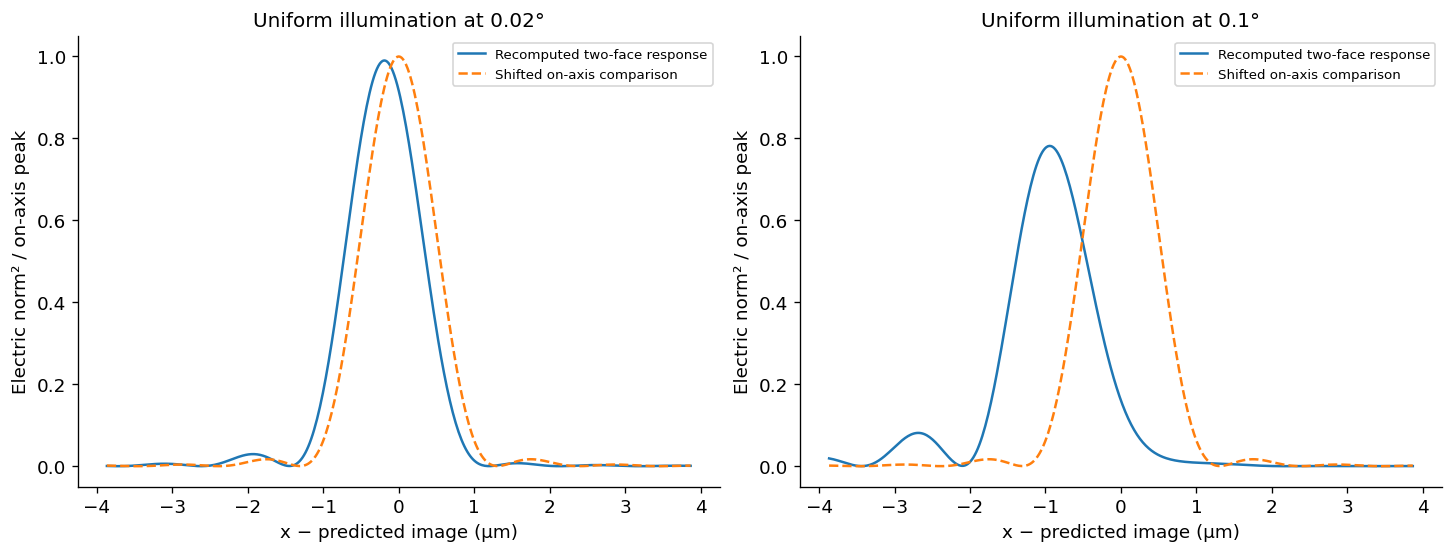

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")

for ax, angle, values in zip(axes, angles[1:], lines[1:]):
    ax.plot(line_x * 1e3, values / lines[0].max(), label="Recomputed two-face response")
    ax.plot(
        line_x * 1e3,
        lines[0] / lines[0].max(),
        "--",
        label="Shifted on-axis comparison",
    )
    ax.set(
        xlabel="x − predicted image (µm)",
        ylabel="Electric norm² / on-axis peak",
        title=f"Uniform illumination at {angle:g}°",
    )
    ax.legend(fontsize=8)

show(fig, "09_two_interface_off_axis")

## 4b. Recover a finite stigmatic object–image pair

Replace the entrance face by the Cartesian oval designed for the object
$A=(0,0,-20)$ mm and its in-glass conjugate $(0,0,30)$ mm. The same exit
sphere then forms the image at $(0,0,40)$ mm. Its entrance radius is 1.5 mm.
The input uses a spherical phase $L=|r-A|$ and a transverse dipole-like
$1/|r-A|$ envelope at leading high-frequency order.

A displaced object at $A_x=50$ µm uses **unchanged surfaces**. The paraxial
magnification $-2.25$ selects the observation centre; it does not shift a
precomputed image. This recovers the specialized finite-conjugate use case
within the same transport algorithm and then tests departure from stigmatism.

In [10]:
# Recover finite-conjugate fields from unchanged physical surfaces.

from examples.macroscopic_element import finite_conjugate_response

fx = np.linspace(-25, 25, 161) * wavelength
FX, FY = np.meshgrid(fx, fx)
finite_fields = []
finite_results = []

for offset in [0.0, 0.05]:
    start = time.perf_counter()
    state, ff = finite_conjugate_response((offset, 0, -20.0), wavelength=wavelength)
    elapsed = time.perf_counter() - start

    # Move the observation window; the physical surfaces remain fixed.
    center = ff + [-2.25 * offset, 0, 0]
    field = state.transmitted.evaluate_local(
        center + np.stack((FX, FY, 0 * FX), axis=-1),
        radius=5 * wavelength,
        backend="auto",
    ).electric

    finite_fields.append(field)
    finite_results.append(state)
    print(f"Finite object x={offset * 1e3:g} µm: two-face transport {elapsed:.4f} s")

end = finite_results[0].modes[0][-1]
assert (
    np.ptp(end.optical_path + np.linalg.norm(ff - end.sampling.points, axis=-1))
    / wavelength
    < 1e-7
)
finite_peak = np.sum(abs(finite_fields[0]) ** 2, axis=-1).max()

Finite object x=0 µm: two-face transport 0.0475 s


Finite object x=50 µm: two-face transport 0.0503 s


**Read the result:** Finite-conjugate maps use the same physical surfaces for both objects.

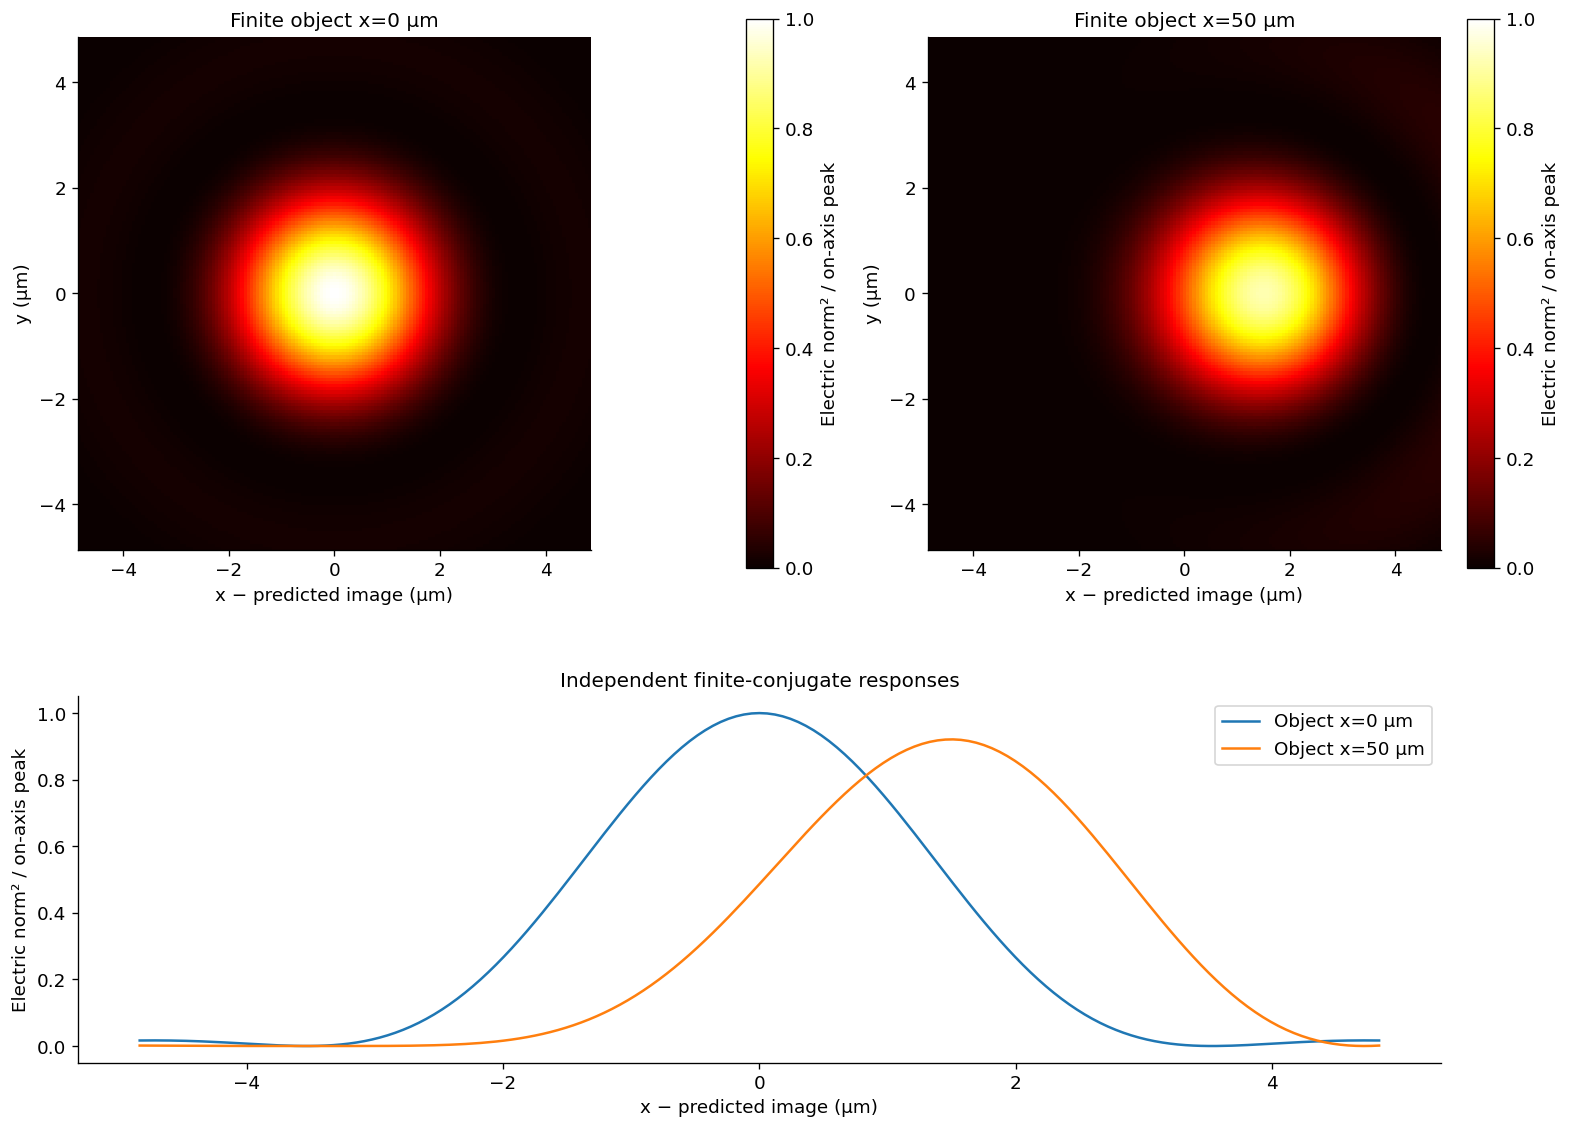

In [11]:
# Give the two square physical maps equal slots above the nonspatial lineout.
fig = plt.figure(figsize=(13, 10), layout="constrained")
grid = fig.add_gridspec(2, 2, height_ratios=[2, 1])
axes = [
    fig.add_subplot(grid[0, 0]),
    fig.add_subplot(grid[0, 1]),
    fig.add_subplot(grid[1, :]),
]

for ax, field, offset in zip(axes[:2], finite_fields, [0.0, 50.0]):
    scalar_map(
        fig,
        ax,
        np.sum(abs(field) ** 2, axis=-1) / finite_peak,
        fx * 1e3,
        fx * 1e3,
        f"Finite object x={offset:g} µm",
        xlabel="x − predicted image (µm)",
        ylabel="y (µm)",
        label="Electric norm² / on-axis peak",
        vmax=1,
    )
    axes[2].plot(
        fx * 1e3,
        np.sum(abs(field[len(fx) // 2]) ** 2, axis=-1) / finite_peak,
        label=f"Object x={offset:g} µm",
    )

axes[2].set(
    xlabel="x − predicted image (µm)",
    ylabel="Electric norm² / on-axis peak",
    title="Independent finite-conjugate responses",
)
axes[2].legend()
show(fig, "09_finite_conjugates")

## 5. Measure the approximation and its computational cost

There are two separate comparisons:

1. Transport 625 incident Gaussian-spectrum components independently, and compare
   the incident field at the second face with **direct full-Green propagation**
   of the first-face currents. Refine that direct quadrature independently.
2. At 193.368 nm, compare the final two-face image field using one Gaussian
   eikonal with the image from 625 transported components. Both use the same
   high-frequency inter-face approximation. The final radiation in this timed
   comparison uses the full Green kernel at 17 image points.

The second comparison measures phase compression; it must not be described as
an exact full-Maxwell error or speedup. The beam spectrum is refined to 25×25
Gauss–Hermite modes; the field amplitude at its truncation edge is below $10^{-5}$.

In [12]:
# Compare inter-face transport and phase compression with direct references.

from benchmarks.high_frequency_transport import propagation_case

report = json.loads(
    (root / "benchmarks/results/high_frequency_transport.json").read_text()
)
fresh = propagation_case(100)

# Test the direct reference and source quadrature before timing.
assert fresh["reference_converged"]
assert fresh["complex_EH_relative_error"] < 0.001
rows = report["propagation"]
compression = report["macroscopic_compression"]
assert all(r["reference_converged"] for r in rows)
assert compression["multiple_phase_source_quadrature_change"] < 1e-7

**Read the result:** Separate reference error, transport time, and phase-compression cost.

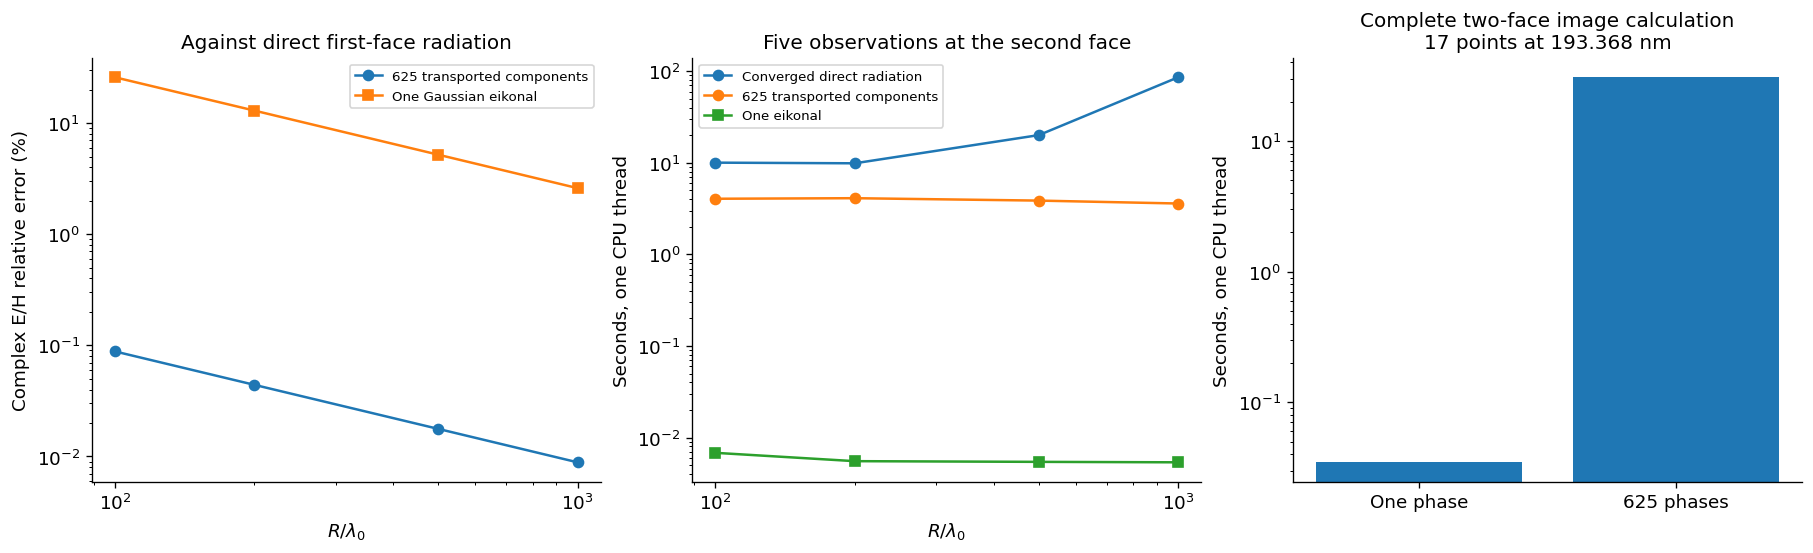

Single-phase image error relative to 625-phase transport: 0.02176%
Image calculation: 0.0347 s versus 30.793 s; 887.5× speedup
625-phase surface-quadrature change: 1.682e-11


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), layout="constrained")

# First panel: field error against direct first-face radiation.
size = [r["radius_over_wavelength"] for r in rows]
axes[0].loglog(
    size,
    [100 * r["complex_EH_relative_error"] for r in rows],
    "o-",
    label="625 transported components",
)
axes[0].loglog(
    size,
    [100 * r["single_phase_relative_error"] for r in rows],
    "s-",
    label="One Gaussian eikonal",
)
axes[0].set(
    xlabel=r"$R/\lambda_0$",
    ylabel="Complex E/H relative error (%)",
    title="Against direct first-face radiation",
)
axes[0].legend(fontsize=8)

# Second panel: time for the same held observations.
axes[1].loglog(
    size,
    [r["direct_seconds"][-1] for r in rows],
    "o-",
    label="Converged direct radiation",
)
axes[1].loglog(
    size,
    [r["transport_seconds"] for r in rows],
    "o-",
    label="625 transported components",
)
axes[1].loglog(
    size, [r["single_phase_seconds"] for r in rows], "s-", label="One eikonal"
)
axes[1].set(
    xlabel=r"$R/\lambda_0$",
    ylabel="Seconds, one CPU thread",
    title="Five observations at the second face",
)
axes[1].legend(fontsize=8)

# Third panel: full two-face image cost for one or many phases.
axes[2].bar(
    ["One phase", "625 phases"],
    [compression["single_phase_seconds"], compression["multiple_phase_seconds"][-1]],
)
axes[2].set(
    yscale="log",
    ylabel="Seconds, one CPU thread",
    title="Complete two-face image calculation\n17 points at 193.368 nm",
)
show(fig, "09_transport_performance")
print(
    f"Single-phase image error relative to 625-phase transport: {100 * compression['single_vs_multiple_phase_relative_EH_error']:.5f}%"
)
print(
    f"Image calculation: {compression['single_phase_seconds']:.4f} s versus {compression['multiple_phase_seconds'][-1]:.3f} s; {compression['speedup']:.1f}× speedup"
)
print(
    f"625-phase surface-quadrature change: {compression['multiple_phase_source_quadrature_change']:.3e}"
)

## 6. Check flux, Fresnel identities and numerical sampling separately

Ray-tube flux conservation checks the transported amplitudes. The local
Fresnel identities are checked at both encounters, but their success is **not**
reconstructed global Maxwell boundary closure; notebook 07 addresses that
distinction. Doubling numerical resolutions must not be confused with reducing
the omitted high-frequency wave correction.

In [14]:
# Check local Fresnel laws, ray-tube power, and final-current refinement.

for j, (interface, record) in enumerate(zip(assembly.interfaces, result.modes[0])):
    b = record.boundary
    q = record.sampling
    residual = boundary_residuals(
        b.incident_E + b.reflected_E,
        b.incident_H + b.reflected_H,
        b.transmitted_E,
        b.transmitted_H,
        q.normals,
        interface.incident_medium,
        interface.transmitted_medium,
        electric_scale=1,
        magnetic_scale=interface.incident_medium.n,
    )
    flux = lambda E, H: np.sum(np.sum(poynting(E, H) * q.normals, axis=-1) * q.weights)
    pin, pr, pt = (
        flux(b.incident_E, b.incident_H),
        flux(b.reflected_E, b.reflected_H),
        flux(b.transmitted_E, b.transmitted_H),
    )
    assert abs(pin + pr - pt) / pin < 1e-10
    print(
        f"Face {j + 1}: local Fresnel residual={max(residual.values()):.3e}; reflected power={-pr / pin:.6f}; transmitted power={pt / pin:.6f}"
    )

# Refine final-current quadrature and derivative step at held observations.

Face 1: local Fresnel residual=1.458e-16; reflected power=0.040001; transmitted power=0.959999
Face 2: local Fresnel residual=2.219e-16; reflected power=0.040000; transmitted power=0.960000


**Next step:** Refine the final current radiation at held-out image points.

In [15]:
held = focus + wavelength * np.array(
    [[-10, 0, -40], [-3, 2, 0], [0, 0, 0], [4, -2, 20], [10, 0, 40]]
)
full = result.transmitted.evaluate(held)
fine, _ = response(
    wavelength=wavelength,
    waist=1.0,
    nr=96,
    nphi=192,
    derivative_step=result.derivative_step / 2,
)
refined = fine.transmitted.evaluate(held)
relative = np.linalg.norm(
    np.concatenate(full, axis=-1) - np.concatenate(refined, axis=-1)
) / np.linalg.norm(np.concatenate(refined, axis=-1))
assert relative < 1e-7
print(f"Final-current quadrature and derivative-step change: {relative:.3e}")

Final-current quadrature and derivative-step change: 1.754e-11


**Usable scope:** this is now an implemented multi-interface macroscopic
approximation with measured performance, optical phase, vector Fresnel laws,
spreading and final image diffraction. A known smooth phase can be very much
cheaper than carrying hundreds of spectral components. The small-element
results show why that reduction cannot be applied indiscriminately: the
single-phase Gaussian approximation is inaccurate there.

Intermediate caustics and stops need wave corrections or a different supported
representation; metallic/coated mirrors and closed-body feedback remain pending.
Full folded DUV prescriptions have not been validated by this two-face example.